# 결정트리 회귀 · SVC · SVR 복습 문제지 (실습형)
### DecisionTreeRegressor · SVM 분류/회귀 · 마진 · 커널

> **사용법**: 이번엔 직접 코딩한다. 각 문제의 지시대로 코드를 짜고 출력을 확인한 뒤, **사고 과제**에 답하라. 정답 코드와 해설은 별도 해설지에 있다. 막히면 먼저 스스로 시도하고, 그 다음 해설을 펴라.
> **데이터**: California housing, iris, make_moons, 사인곡선 샘플
> **구성**: 3개 레벨 × 5문제 = 총 15문제
>
> **오늘의 큰 그림**: 세 덩어리. **결정트리 회귀**는 어제 분류 트리의 확장 — 구조는 같고 leaf 결과만 다르다(다수결 → 평균). **SVC**는 "마진"이라는 새 기준으로 경계를 찾는다. **SVR**은 그 아이디어를 회귀로 확장한 "epsilon tube". 그리고 여기서 **PCA(차원축소)**가 시각화 도구로 처음 등장한다.

## 공통 준비 코드

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.svm import SVC, SVR
from sklearn.datasets import load_iris, make_moons
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, classification_report
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.svm import SVC, SVR
from sklearn.datasets import load_iris, make_moons
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, classification_report

# LEVEL 1 — 도구 장악
> 세 모델을 직접 돌려보고 출력 모양을 눈으로 확인한다.

---

### 문제 1-1. 결정트리 회귀 — leaf가 평균을 반환한다

California housing 데이터로 `DecisionTreeRegressor(max_depth=3)`를 학습시켜라. 그리고:
1. 학습/평가 R²를 각각 출력
2. `plot_tree(model, max_depth=2, filled=True)`로 트리를 그려라
3. 트리 그림에서 leaf 노드의 `value`가 무엇을 의미하는지 확인하라

**사고 과제**: 분류 트리의 leaf `value`는 "클래스별 개수"였는데, 회귀 트리의 leaf `value`는 무엇인가? 왜 회귀 트리는 다수결이 아니라 평균을 쓰는지, target이 연속형 숫자라는 점과 연결해 설명하라.

학습셋: 0.5378979887726012
평가셋: 0.5097629887358219


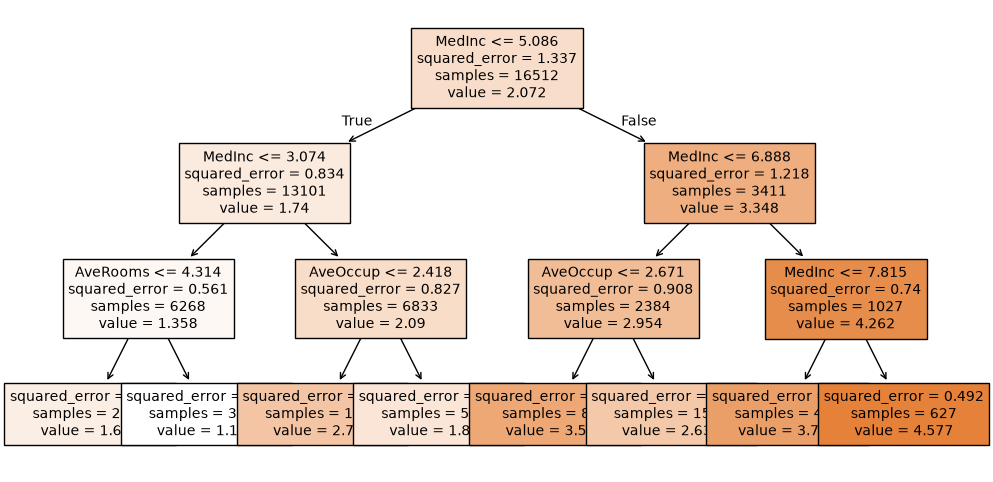

In [14]:
house_df = pd.read_csv("./../04_decision_tree_svm/data/california_housing.csv")

key_data_name = house_df.drop(columns="MedHouseVal").columns.tolist()
X = house_df[key_data_name]
y = house_df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeRegressor(random_state=42, max_depth=3)
model.fit(X_train, y_train)
print("학습셋:", model.score(X_train, y_train))
print("평가셋:", model.score(X_test, y_test))

plt.figure(figsize = (12,6))
plot_tree(model, filled=True, feature_names=key_data_name, max_depth=3, fontsize=10)
plt.show()

### 문제 1-2. 회귀 트리의 max_depth 3종 비교

`max_depth`를 `[None, 3, 8]`로 바꿔가며 각각 학습하고, 학습 R²와 평가 R²를 표로 비교하라.

```python
for depth in [None, 3, 8]:
    model = DecisionTreeRegressor(random_state=42, max_depth=depth)
    # 학습, 예측, R² 계산
```

**사고 과제**: `max_depth=None`일 때 학습 R²는 거의 1.0인데 평가 R²는 훨씬 낮을 것이다. 이 격차가 무엇을 의미하나? 어제 분류 트리에서 본 것과 같은 현상인가?

In [20]:
result_df = []

for depth in [None, 3, 8]:
    model = DecisionTreeRegressor(random_state=42, max_depth=depth)
    model.fit(X_train, y_train)
    actual_r2 = model.score(X_train, y_train)
    predicted_r2 = model.score(X_test, y_test)

    result_df.append([depth, actual_r2, predicted_r2])

result_df = pd.DataFrame(result_df, columns = ['depth', 'actual_r2', 'predicted_r2'])
result_df

,depth,actual_r2,predicted_r2
0,NaN,1.000000,0.622823
1,3.0,0.537898,0.509763
2,8.0,0.760173,0.677928


### 문제 2-1. 회귀 트리는 외삽을 못 한다

`max_depth=8` 회귀 트리를 학습시킨 뒤, **학습 데이터 범위를 벗어난 극단적 입력**(예: MedInc를 학습 최댓값보다 훨씬 큰 값)으로 예측해보라. 여러 극단값을 넣어 예측이 어떻게 나오는지 관찰하라.

**사고 과제**: 회귀 트리도 KNN 회귀처럼 학습 범위 밖에서는 새로운 추세를 못 만든다. 범위 밖 입력은 결국 "가장 가까운 leaf의 평균"으로 예측된다. 왜 트리 구조상 외삽이 불가능한지, leaf가 "고정된 평균값"이라는 점으로 설명하라. (KNN 외삽 한계와 같은 뿌리)

In [32]:
model = DecisionTreeRegressor(max_depth=8, random_state=42)
model.fit(X_train, y_train)
print("학습셋:", model.score(X_train, y_train))
base = X_train.median()
extreme = pd.DataFrame([base, base, base])
extreme['MedInc'] = [20, 50, 100]
print(model.predict(extreme[X_train.columns]))

학습셋: 0.7601733883178262
[4.96077044 4.96077044 4.96077044]
